### 1. Import Library

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### I use pandas for data manipulation, numpy for numerical operations, and matplotlib/Seaborn for Visualisation. These libraries are sufficient for exploring structured datasets and presenting findings clearly

### 2. Load Data (reference_pricing_data.csv)

In [56]:
df_pricing_data = pd.read_csv("../data/reference_pricing_data.csv")

In [57]:
df_pricing_data.head()

,scrape_date,scrape_timestamp,scrape_id,retailer,product_id,product_name,category,selling_price,reference_price,reference_label,promotion_name,page_url
0,01/01/2024,01/01/2024 18:18,SCR-F731267B731B,RETAILER A,RET-PROD-001,Wireless Soundbar 494,Audio,NaN,NaN,NaN,NaN,https://www.retailera.co.uk/products/wireless-...
1,02/01/2024,02/01/2024 15:10,SCR-0A6A04C92C6F,Retailer-A,RET-PROD-001,Wireless Soundbar 494,Audio,308.99,NaN,NaN,NaN,https://www.retailera.co.uk/products/wireless-...
2,03/01/2024,03/01/2024 06:45,SCR-C8FFBFBE7D68,Ret. A,RET-PROD-001,Wireless Soundbar 494,Audio,308.99,NaN,NaN,NaN,https://www.retailera.co.uk/products/wireless-...
3,04/01/2024,04/01/2024 17:25,SCR-3FDD73A42E4C,RetailerA,RET-PROD-001,Wireless Soundbar 494,Audio,308.99,NaN,NaN,NaN,https://www.retailera.co.uk/products/wireless-...
4,05/01/2024,05/01/2024 08:35,SCR-4E9B8042FC55,Retailer-A,RET-PROD-001,Wireless Soundbar 494,Audio,308.99,NaN,NaN,NaN,https://www.retailera.co.uk/products/wireless-...


In [58]:
df_pricing_data.shape

(2727, 12)

### 3. Introduction
This analysis explores pricing behaviour across a set of online retailers, with a focus on how reference prices (e.g. "Was £100, now £60") are used.
Reference pricing can influence consumer decisions, but if not applied appropriately, it may risk misleading consumers about the true level of savings.
The aim of this analysis is to identify patterns in the data that may indicate potentially misleading reference pricing practices, assess how widespread these behaviours are, and provide insights that could support further investigation.

### 4. Data Cleaning

In [59]:
retailer_name = df_pricing_data["retailer"].unique()

retailer_name

array(['RETAILER A', 'Retailer-A', 'Ret. A', 'RetailerA', 'Retailer A',
       'retailer a', 'RETAILER B', 'Retailer B.', 'Retailer B',
       'retailer b', 'RETAILER E', 'Ret. E', 'Retailer E', 'retailer e',
       'Retailer-E', 'retailer d', 'RetailerD', 'Retailer D Ltd',
       'Retailer D', 'RetailerB', 'Retailer C', 'Retailer  C', 'Ret C',
       'RETAILER C', 'retailer c'], dtype=object)

In [60]:
# Standardise retailer
df_pricing_data['retailer'] = (
    df_pricing_data['retailer']
    .str.upper()
    .str.replace(r'[^A-Z0-9]', '', regex=True)
)

# 2. Refined mapping to catch all remaining variants
retailer_map = {
    "RETAILERA": "RETAILER_A", "RETA": "RETAILER_A",
    "RETAILERB": "RETAILER_B", "RETAILERB": "RETAILER_B",
    "RETAILERC": "RETAILER_C", "RETC": "RETAILER_C",
    "RETAILERD": "RETAILER_D", "RETAILERDLTD": "RETAILER_D",
    "RETAILERE": "RETAILER_E", "RETE": "RETAILER_E"
}

df_pricing_data["retailer"] = df_pricing_data["retailer"].replace(retailer_map)

# Convert dates
df_pricing_data["scrape_date"] = pd.to_datetime(df_pricing_data["scrape_date"], dayfirst=True)

# Convert prices
df_pricing_data["selling_price"] = pd.to_numeric(df_pricing_data["selling_price"], errors="coerce")
df_pricing_data["reference_price"] = pd.to_numeric(df_pricing_data["reference_price"], errors="coerce")

# Remove rows with no selling price
df_pricing_data = df_pricing_data.dropna(subset=["selling_price"])

# Remove invalid prices
df_pricing_data = df_pricing_data[df_pricing_data["selling_price"] > 0]

# Fill missing reference prices
df_pricing_data["reference_price"] = df_pricing_data["reference_price"].fillna(0)

# Sort data
df_pricing_data = df_pricing_data.sort_values(["product_id", "scrape_date"])

# Drop duplicates
df_pricing_data = df_pricing_data.drop_duplicates()

###  The dataset was cleaned to ensure consistency and reliability. Retailer names were standardised to avoid fragmentation, and invalid or unusable rows were removed. Missing reference prices were treated as no promotion.

In [61]:
df_pricing_data_clean  = df_pricing_data.copy()

df_pricing_data_clean

,scrape_date,scrape_timestamp,scrape_id,retailer,product_id,product_name,category,selling_price,reference_price,reference_label,promotion_name,page_url
1,2024-01-02,02/01/2024 15:10,SCR-0A6A04C92C6F,RETAILER_A,RET-PROD-001,Wireless Soundbar 494,Audio,308.99,0.00,NaN,NaN,https://www.retailera.co.uk/products/wireless-...
2,2024-01-03,03/01/2024 06:45,SCR-C8FFBFBE7D68,RETAILER_A,RET-PROD-001,Wireless Soundbar 494,Audio,308.99,0.00,NaN,NaN,https://www.retailera.co.uk/products/wireless-...
3,2024-01-04,04/01/2024 17:25,SCR-3FDD73A42E4C,RETAILER_A,RET-PROD-001,Wireless Soundbar 494,Audio,308.99,0.00,NaN,NaN,https://www.retailera.co.uk/products/wireless-...
4,2024-01-05,05/01/2024 08:35,SCR-4E9B8042FC55,RETAILER_A,RET-PROD-001,Wireless Soundbar 494,Audio,308.99,0.00,NaN,NaN,https://www.retailera.co.uk/products/wireless-...
5,2024-01-06,06/01/2024 16:05,SCR-5EADC68C55F1,RETAILER_A,RET-PROD-001,Wireless Soundbar 494,Audio,308.99,0.00,NaN,NaN,https://www.retailera.co.uk/products/wireless-...
...,...,...,...,...,...,...,...,...,...,...,...,...
2076,2024-03-29,29/03/2024 22:40,SCR-AB6A58BEE427,RETAILER_D,NaN,Advanced Webcam 292,computing,652.45,0.00,NaN,NaN,https://www.retailerd.co.uk/products/advanced-...
1087,2024-03-30,30/03/2024 10:50,SCR-F77B0123E761,RETAILER_A,NaN,Pro Mouse 527,Computing,553.85,0.00,NaN,NaN,https://www.retailera.co.uk/products/pro-mouse...
1987,2024-03-30,30/03/2024 19:27,SCR-4A3606ED39E4,RETAILER_A,NaN,Classic Amplifier 373,electronics,47.49,68.94,Was,NaN,https://www.retailera.co.uk/products/classic-a...
2352,2024-03-30,30/03/2024 20:22,SCR-2B31C1330443,RETAILER_C,NaN,Smart Monitor 831,Computing,495.37,0.00,NaN,NaN,https://www.retailerc.co.uk/products/smart-mon...


### 5. Feature Engineering

In [62]:
# Discount %
df_pricing_data_clean["discount_pct"] = (df_pricing_data_clean["reference_price"] - df_pricing_data_clean["selling_price"]) / df_pricing_data_clean["reference_price"]

# Discount flag
df_pricing_data_clean["is_discounted"] = df_pricing_data_clean["reference_price"].notna()

# Average price per product
df_pricing_data_clean["avg_price"] = df_pricing_data_clean.groupby("product_id")["selling_price"].transform("mean")

### Additional variables were created to support the analysis. A discount percentage was calculated to quantify the difference between reference and selling prices.
A binary flag identifies whether a product is presented with a reference price, and an average selling price per product was used as a baseline to assess whether reference prices appear inflated.

### 6. Defining Misleading Behaviour

### 1. Inflated reference price

In [63]:
df_pricing_data_clean["flag_inflated"] = df_pricing_data_clean["reference_price"] > (1.2 * df_pricing_data_clean["avg_price"])


### 2. Always discounted

In [64]:
discount_ratio = df_pricing_data_clean.groupby("product_id")["is_discounted"].transform("mean")
df_pricing_data_clean["flag_always_discounted"] = discount_ratio > 0.8

### 3. High Discount

In [65]:
df_pricing_data_clean["flag_high_discount"] = df_pricing_data_clean["discount_pct"] > 0.5

###  Severity Score

In [66]:

df_pricing_data_clean["severity_score"] = (
    df_pricing_data_clean["flag_inflated"].astype(int) +
    df_pricing_data_clean["flag_always_discounted"].astype(int) +
    df_pricing_data_clean["flag_high_discount"].astype(int)
)

### As there is no single rule for identifying misleading reference pricing, a set of indicators was defined.
Reference prices significantly higher than the typical selling price were flagged as potentially inflated. Products that appear discounted for most of the observed period were also flagged, as this may indicate that the reference price is not genuinely representative.
Additionally, very high discount levels were used as an indicator of potential concern. These indicators are intended to highlight patterns for further investigation rather than provide definitive conclusions.

### 7. Analysis

In [67]:
# Aggregate by retailer
retailer_flags = df_pricing_data_clean.groupby("retailer")[[
    "flag_inflated",
    "flag_always_discounted",
    "flag_high_discount"
]].mean().reset_index()

retailer_flags

,retailer,flag_inflated,flag_always_discounted,flag_high_discount
0,RETAILER_A,0.185930,0.959799,0.000000
1,RETAILER_B,0.060284,0.957447,0.024823
2,RETAILER_C,0.236538,0.976923,0.084615
3,RETAILER_D,0.403704,0.959259,0.000000
4,RETAILER_E,0.170968,0.951613,0.000000


In [68]:
# Aggregate by product
product_flags = df_pricing_data_clean.groupby("product_id")[[
    "flag_inflated",
    "flag_always_discounted",
    "flag_high_discount"
]].mean()

product_flags

,flag_inflated,flag_always_discounted,flag_high_discount
product_id,,,
RET-PROD-001,0.235294,1.0,0.000000
RET-PROD-002,0.000000,1.0,0.000000
RET-PROD-003,0.000000,1.0,0.000000
RET-PROD-004,0.460674,1.0,0.000000
RET-PROD-005,0.190476,1.0,0.000000
RET-PROD-006,0.000000,1.0,0.000000
RET-PROD-007,0.500000,1.0,0.000000
RET-PROD-008,0.077778,1.0,0.077778
RET-PROD-009,0.488372,1.0,0.000000


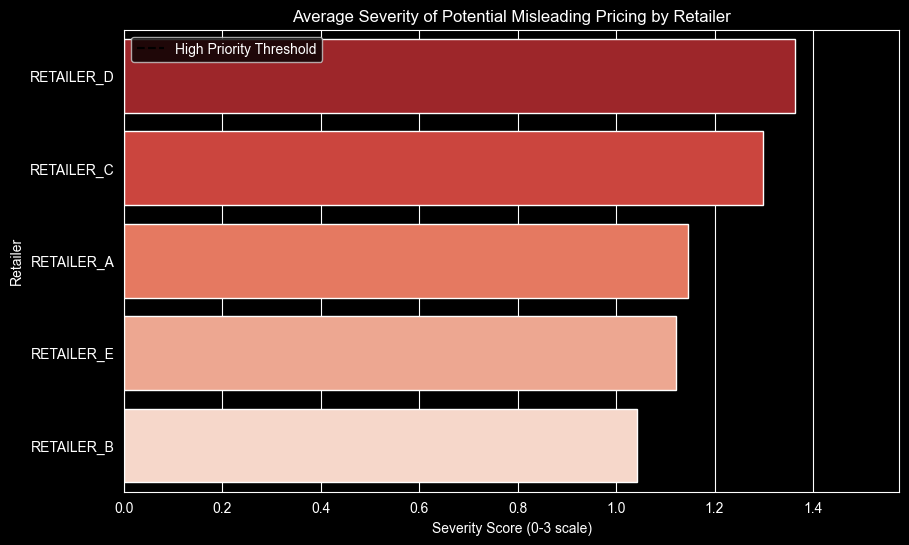

In [73]:
# Aggregate severity by retailer
retailer_severity = df_pricing_data_clean.groupby("retailer")["severity_score"].mean().sort_values(ascending=False).reset_index()

# Visualise
plt.figure(figsize=(10, 6))

sns.barplot(
    data=retailer_severity,
    x="severity_score",
    y="retailer",
    hue="retailer",
    palette="Reds_r",
    legend=False
)

plt.title("Average Severity of Potential Misleading Pricing by Retailer")
plt.xlabel("Severity Score (0-3 scale)")
plt.ylabel("Retailer")

plt.axvline(x=1.5, color='black', linestyle='--', label='High Priority Threshold')
plt.legend()

plt.show()

### The analysis was conducted at both product and retailer level.
At a product level, the focus was on identifying how frequently each product exhibited indicators of concern. At a retailer level, the aim was to assess whether certain retailers show a higher concentration of flagged behaviour, which may indicate systematic practices.

### 8. Visualisations

### 1. Flags by Retailer

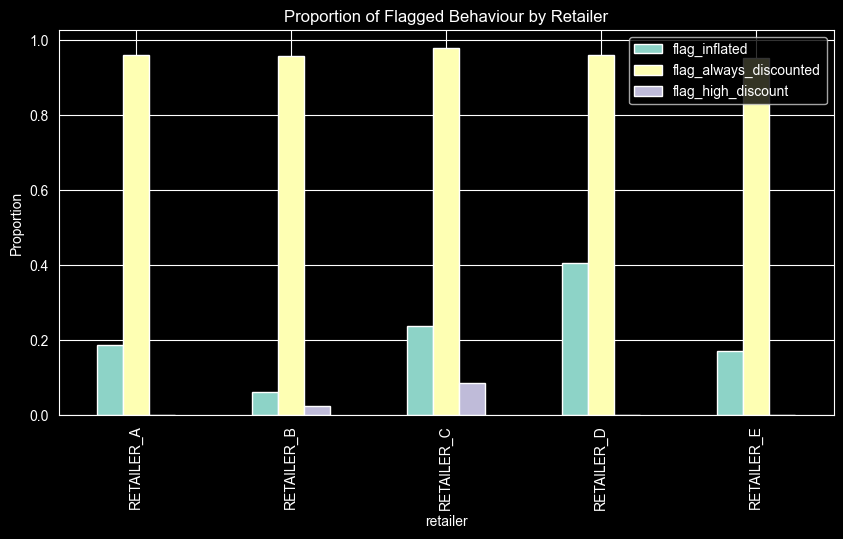

In [70]:
retailer_flags.set_index("retailer").plot(kind="bar", figsize=(10,5))
plt.title("Proportion of Flagged Behaviour by Retailer")
plt.ylabel("Proportion")
plt.show()

### 2. Discount Distribution

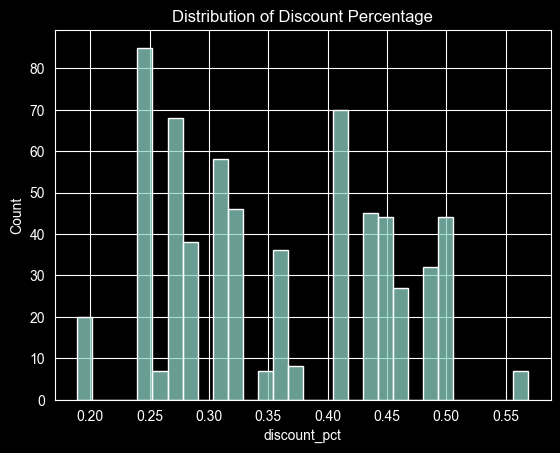

In [71]:
sns.histplot(df_pricing_data_clean["discount_pct"].dropna(), bins=30)
plt.title("Distribution of Discount Percentage")
plt.show()

### 3. Example Time Series

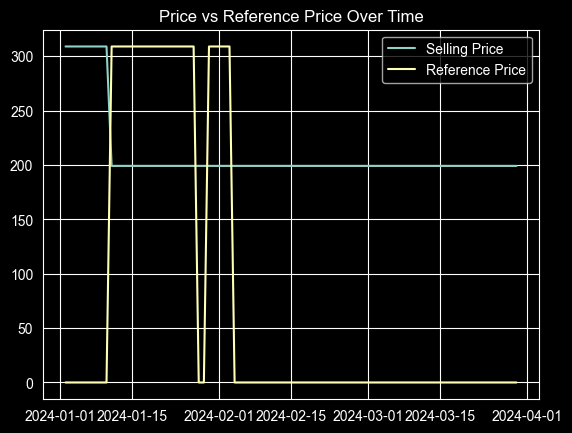

In [72]:
sample_product = df_pricing_data_clean[df_pricing_data_clean["product_id"] == df_pricing_data_clean["product_id"].iloc[0]]

plt.plot(sample_product["scrape_date"], sample_product["selling_price"], label="Selling Price")
plt.plot(sample_product["scrape_date"], sample_product["reference_price"], label="Reference Price")
plt.legend()
plt.title("Price vs Reference Price Over Time")
plt.show()

### Visualisations were used to highlight patterns in pricing behaviour, including how discount levels are distributed and how flagged behaviour varies across retailers.
Time-series plots were also used to illustrate how reference prices compare to selling prices over time for individual products.

### 9. Key Insights

### The analysis suggests that potentially misleading reference pricing may be present across a notable proportion of products. A number of products appear to be discounted for most of the observed period, which raises questions about whether the reference price reflects a genuine previous price.
In addition, some reference prices are consistently higher than the product’s typical selling price, indicating that advertised discounts may overstate actua
 savings. There is also variation across retailers, with some showing a higher concentration of flagged behaviour than others.
While these findings are not conclusive, they highlight patterns that could warrant further regulatory review.

### 10. Assumptions

### This analysis assumes that a genuine reference price should reflect a price that was used for a meaningful period. Thresholds such as 20% above average price and 80% discount frequency were used as practical indicators of potential concern. These thresholds are not definitive and could be refined with additional data or policy guidance.

### 11. Limitations

### The dataset does not include information on how long a reference price was displayed to consumers or on actual sales volumes, which limits the ability to assess consumer impact directly. In addition, the time period covered may not fully reflect longer-term pricing behaviour. As a result, the findings should be interpreted as indicative rather than conclusive.